In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.metrics import *


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure',
           'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)


In [39]:
X = df.drop(columns=['Outcome'])
y= df['Outcome'].values

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
def knn(X_train, y_train, X_test, k):
    predictions = []
    for test in X_test:
        distance = np.sqrt(np.sum((X_train-test)**2,axis=1))
        k_labels = y_train[np.argsort(distance)[:k]]
        predictions.append(np.bincount(k_labels).argmax())
    return predictions

In [46]:
for k in [1,2,3,5,7,9]:
    y_pred = knn(X_train, y_train, X_test, k)
    print("K: ",k,"\naccuracy: ", accuracy_score(y_pred, y_test))

K:  1 
accuracy:  0.6233766233766234
K:  2 
accuracy:  0.6558441558441559
K:  3 
accuracy:  0.7077922077922078
K:  5 
accuracy:  0.6948051948051948
K:  7 
accuracy:  0.6818181818181818
K:  9 
accuracy:  0.6818181818181818


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

In [4]:
data = load_diabetes()

In [24]:
# X = data.data
# y=data.target
import pandas as pd
df = pd.read_csv("../dataset/diabetes-new.csv")
df.info()
df = df.dropna()
df.Outcome = df.Outcome.astype(int)


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    float64
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             763 non-null    float64
 3   SkinThickness             765 non-null    float64
 4   Insulin                   764 non-null    float64
 5   BMI                       763 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       762 non-null    float64
 8   Outcome                   767 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


In [28]:
X = df.drop(columns=['Outcome']).values
y=df.Outcome.values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
def knn(X,y,X_test,k):
    prediction = []
    for test in X_test:
        distance = np.sqrt(np.sum((test-X)**2,axis=1))
        k_labels = y[np.argsort(distance)[:k]]
        label = np.bincount(k_labels).argmax()
        prediction.append(label)
    return prediction

In [49]:
acc = []
for k in range(20,100,20):
    y_pred = knn(X_train,y_train,X_test,k)
    acc.append([k,accuracy_score(y_test,y_pred)])

    


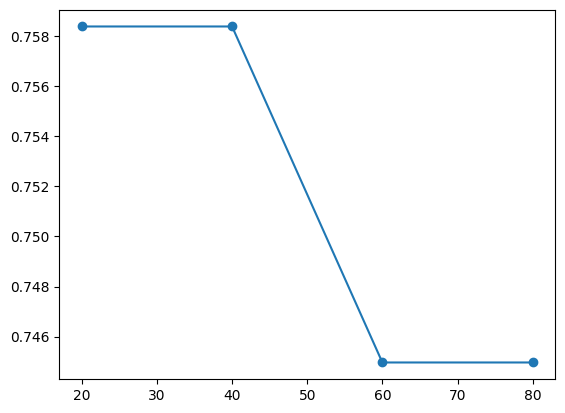

In [50]:
import matplotlib.pyplot as plt
acc = np.array(acc)
plt.plot(acc[:,0],acc[:,1], marker='o')

In [35]:
print(acc)

[[2, 0.7516778523489933], [5, 0.7449664429530202], [10, 0.738255033557047]]


dist_1
dist_2


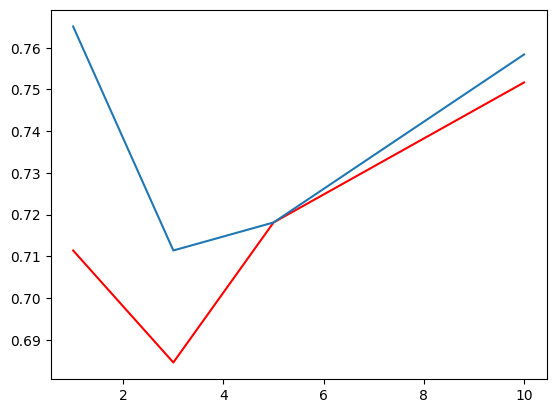

In [60]:
# Build a KNN model for predicting if a person will have diabetes or not with a high accuracy score. 
# erform some appropriate Pre-Processing steps on the given dataset for better results. Implement the 
# KNN algorithm on your own. Try other possible processes that can be done to dataset and tuning the model 
# to increase accuracy such as Increase K value, Normalization and Different Distance Metrics

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def dist_1(a,b):
    return np.sum(np.abs(a-b),axis=1)

def dist_2(a,b):
    return np.sqrt(np.sum((a-b)**2,axis=1))


def knn(X_train, y_train, X_test, k, dist_func):
    pred=[]
    for test in X_test:
        dist = dist_func(X_train,test)
        k_labels = y_train[np.argsort(dist)[:k]]
        p = np.bincount(k_labels).argmax()
        pred.append(p)
    return pred
ks=[1,3,5,10]
dist = [dist_1, dist_2]

df = pd.read_csv('../dataset/diabetes1.csv')
df = df.dropna()
sc = StandardScaler()

X = df.drop(columns=['Outcome']).values
y= df['Outcome'].values.astype(int)



X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

plot_data = []

for d in dist:
    print(d.__name__)
    acc = []
    for k in ks:
        pred = knn(X_train, y_train, X_test, k, d)
        acc.append(accuracy_score(y_test, pred))
    plot_data.append(acc)

plt.plot(ks,plot_data[0],color='r')
plt.plot(ks,plot_data[1])